# Week 3 - Numerical Analysis

Additional References:
- [Google Colab](https://colab.research.google.com/?utm_source=scs-index)
- [Pandas Documentation](https://pandas.pydata.org/docs/index.html)
- [Python for Beginners](https://www.python.org/about/gettingstarted/)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Business Understanding

-  Bank Churn: Customers that defaulted from the credit card company.
- Goal: Understand customers based on bank churn data.

## Data Understanding

### Preliminaries

Step 1. Set up project directory.

```
lastname_project
|---data                          # Directory for source data (*.csv)
    |---churn_test_20240126.csv   # Source data
|---notebook                      # Directory for Colab Notebook (*.ipynb)
    |---lastname_project.ipynb    # Colab Notebook
```

Step 2. Move source data into your Google Drive.

Step 3. Mount your Google Drive.

### Packages

In [4]:
#### Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data

In [5]:
#### Read data
pdf = pd.read_csv('/content/drive/MyDrive/Work/PORTFOLIO/DATA ANALYTICS/Machine Learning Endeavor (Customer Churn)/data/churn_test_20240126.csv')

In [6]:
#### Basic information
pdf.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CLIENTNUM               2026 non-null   int64  
 1   Attrition_Flag          2026 non-null   int64  
 2   Customer_Age            2026 non-null   int64  
 3   Dependent_count         2026 non-null   int64  
 4   Months_Inactive_12_mon  2026 non-null   int64  
 5   Credit_Limit            2026 non-null   float64
 6   Total_Trans_Amt         2026 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 110.9 KB


In [7]:
#### Shape
pdf.shape

(2026, 7)

In [8]:
#### Null
pdf.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Dependent_count,0
Months_Inactive_12_mon,0
Credit_Limit,0
Total_Trans_Amt,0


In [9]:
### Duplicate
pdf.duplicated().sum()

np.int64(0)

In [10]:
#### First 5 rows
pdf.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Dependent_count,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt
0,719455083,0,48,3,3,2991.0,3734
1,773503308,0,59,1,5,2192.0,4010
2,715452408,0,37,2,3,1734.0,4727
3,711264033,0,47,3,2,4786.0,4973
4,718943508,0,42,3,3,3714.0,1454


### Analysis of Single Numeric Variable

#### Customer_Age

In [11]:
#### Count Customer_Age summary statistics
pdf['Customer_Age'].describe()

,Customer_Age
count,2026.000000
mean,46.404245
std,7.995428
min,26.000000
25%,41.000000
50%,46.000000
75%,52.000000
max,73.000000


<Axes: ylabel='Frequency'>

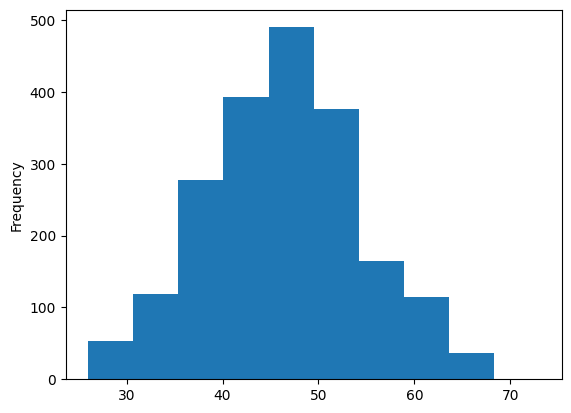

In [12]:
#### Get Customer_Age histogram
pdf['Customer_Age'].plot(kind='hist')

There are less than 100 customers belonging to less than 30 age range, similar situation with the oldest customer age range of 65-70 having less than 50 identified customers. On the other hand, the majority of the customer age range ranges from 40 to mid 50s.

<Axes: >

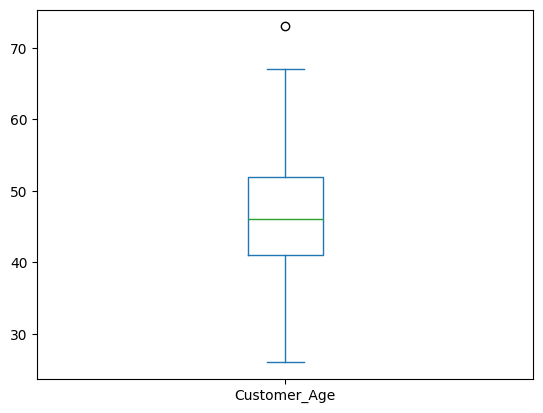

In [13]:
#### Get Customer_Age boxplot
pdf['Customer_Age'].plot(kind='box')

The boxplot represent the interquartile range where most customers fall between 40 and mid 50s as mentioned before, the green line signifying median which could be around 45-47, the whiskers extending above shows the above the average age range which was mid 50s and higher, while below the younger customers. While the "o" could stand for an outlier which means there are some customers which age is higher compared to others, which could be 70-80.

#### Dependent_count

In [14]:
#### Get Dependent_count summary statistics
pdf['Dependent_count'].describe()

,Dependent_count
count,2026.000000
mean,2.391905
std,1.334967
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,5.000000


<Axes: ylabel='Frequency'>

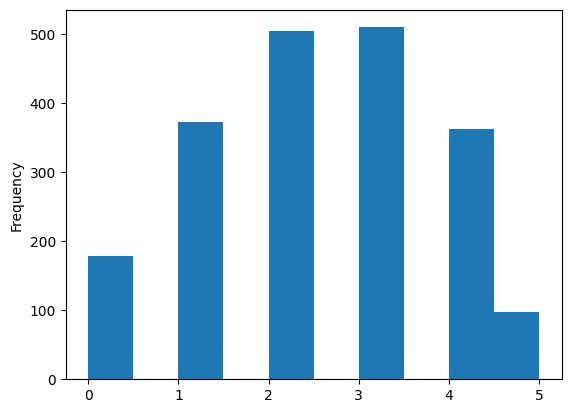

In [15]:
#### Get Dependent_count histogram
pdf['Dependent_count'].plot(kind='hist')

There are less than 200 customers who believe that no supplementarry card is sufficient enough, on the other hand less than 100 said having 5 supplementary card is a huge plus. While the majority of the customers prefer having 2-3 supplementary cards by use case basis.

<Axes: >

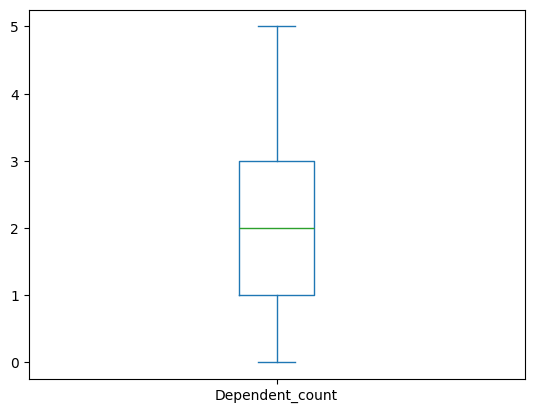

In [16]:
#### Get Dependent_count boxplot
pdf['Dependent_count'].plot(kind='box')

The thickness of the box indicates that the majority of the customers preference of number of supplementary cards/dependent count is between 1 to 3. The green line which is our median signifies that the dependent count is 2 or around it. The whiskers extending below signifying the sentiments of having less to none of it, while above signifying the customers who prefer having 4 to 5 dependencies.

#### Months_Inactive_12_mon

In [17]:
#### Get Months_Inactive_12_mon summary statistics
pdf['Months_Inactive_12_mon'].describe()

,Months_Inactive_12_mon
count,2026.000000
mean,2.318361
std,0.996204
min,0.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,6.000000


In [18]:
#### Count Months_Inactive_12_mon by value
pdf['Months_Inactive_12_mon'].value_counts()

,count
Months_Inactive_12_mon,
3,752
2,671
1,453
4,89
5,34
6,20
0,7


<Axes: ylabel='Frequency'>

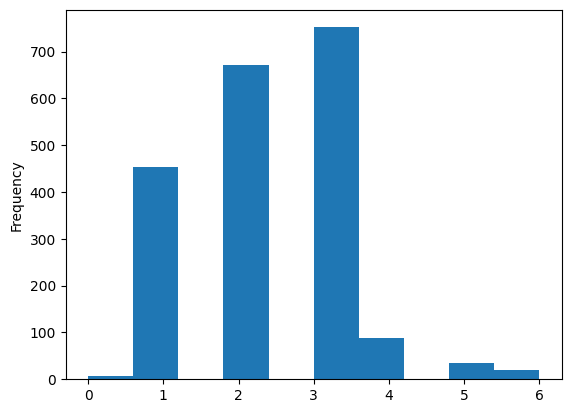

In [19]:
#### Get Months_Inactive_12_mon histogram
pdf['Months_Inactive_12_mon'].plot(kind='hist')

Based on the distribution of the data, there are 7 customers currently in an almost a month hiatus, while there are 453 customers over the month inactive period. Moreover, there are 671 customers on their 2nd month, and 752 on their 3rd. We predict that people on their 4th and 5th month will increase in the coming months if ever the customers remain inactive, as of now they sit on 89 and 34 inactive customers respectively. Finally, only 20 customers are under their 6th month period of inactivity.

<Axes: >

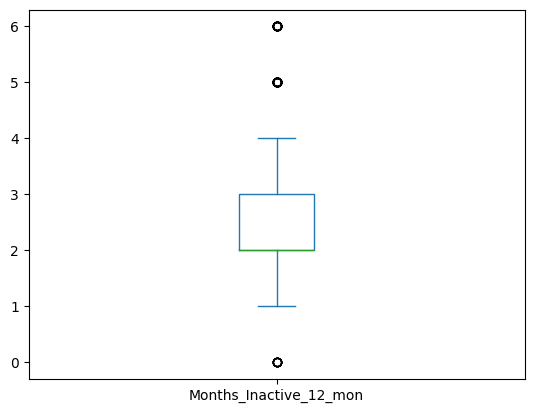

In [20]:
#### Get Months_Inactive_12_mon boxplot
pdf['Months_Inactive_12_mon'].plot(kind='box')

For this one, the box indicates that most of the customers have been inactive in between 2 to 3 months. The median, our green line appears to be around 2 months or so inactivity. The outliers above, specifically in 5th and 6th months indicate that these people are low in numbers tho, they really are far apart from the majority when it comes to inactivity. While the below outlier indicates the sublime number of users which have not yet reached a month of inactivity.

#### Credit_Limit

In [21]:
#### Get Credit_Limit summary statistics
pdf['Credit_Limit'].describe()

,Credit_Limit
count,2026.000000
mean,8613.583021
std,9100.417269
min,1438.300000
25%,2571.250000
50%,4563.500000
75%,10707.500000
max,34516.000000


<Axes: ylabel='Frequency'>

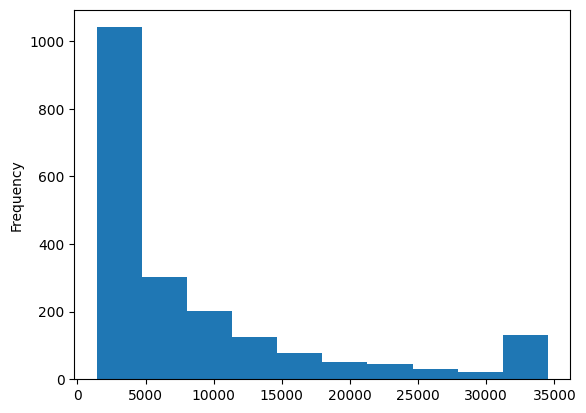

In [22]:
#### Get Credit_Limit histogram
pdf['Credit_Limit'].plot(kind='hist')

Based on the distribution of data, the initial tallest bar indicates that the majority of the customers have around 0 to 5000 credit limit. There is an observed drop in frequency as we move to a higher limit, in to its lowest observed frequecny being in the 25-30k range, all the while at the very end we see a generous amount of customers compared to the previous ones having around 30-35k credit limit.

<Axes: >

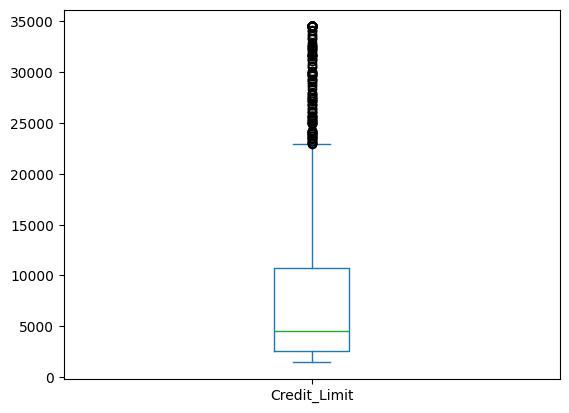

In [23]:
#### Get Credit_Limit boxplot
pdf['Credit_Limit'].plot(kind='box')

The thickness of the box indicates that most of the customers credit limit range fits between 0-10000. The median being around 4-5000 limit range based on the green line. The whisker above indicating the customers which has a higher limit range, but still closer to the interquartile range, while the multitude outlier symbols indicate that all customers having around 25k credit limit or higher is considered to be extremes.

#### Total_Trans_Amt

In [24]:
#### Get Total_Trans_Amt summary statistics
pdf['Total_Trans_Amt'].describe()

,Total_Trans_Amt
count,2026.000000
mean,4408.477295
std,3379.585684
min,530.000000
25%,2147.250000
50%,3908.000000
75%,4750.750000
max,16920.000000


<Axes: ylabel='Frequency'>

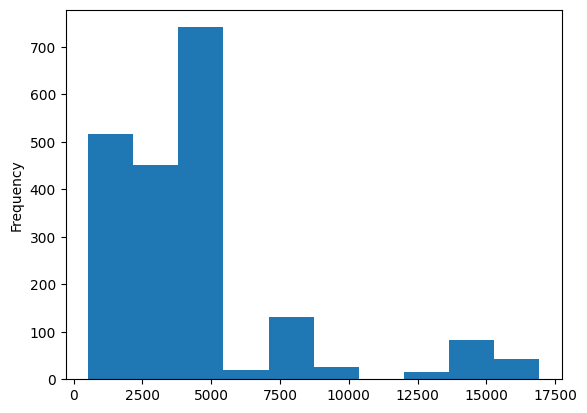

In [25]:
#### Get Total_Trans_Amt histogram
pdf['Total_Trans_Amt'].plot(kind='hist')

Based on the distribution of the data, majority of the customers total transaction amount ranges from 0 to 5000. While looking at the increasing trend of transaction amount, we see a decline, this is more evident as we go along the 10-15k total transaction amount.

<Axes: >

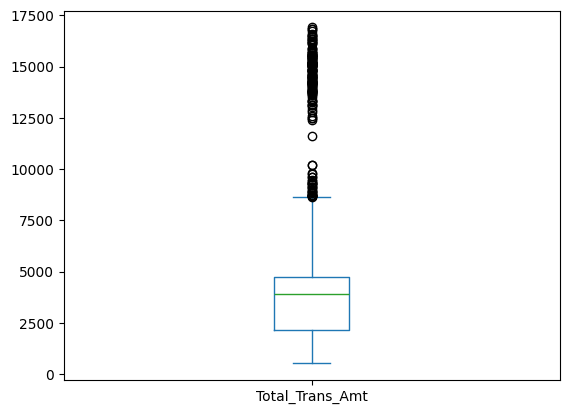

In [26]:
#### Get Total_Trans_Amt box plot
pdf['Total_Trans_Amt'].plot(kind='box')

For this one, the thickness of the box encapsulates the majority of the customers total transaction amount belonging to between 2000-5000 total transaction amount. The lower whiskers denote those with transaction lower than 2000, thile the upper whisker including until somewhere around 8k transaction range. The green line, being our median could be around 4000. While the outliers above the whisker indicate the extreme values, which are total transaction amounts higher than 9000.

### Analysis of Two Numeric Variables

#### Customer_Age vs Dependent_count

In [27]:
#### Get Dependent_count vs Customer_Age correlation
pdf[['Dependent_count', 'Customer_Age']].corr()

,Dependent_count,Customer_Age
Dependent_count,1.000000,-0.149253
Customer_Age,-0.149253,1.000000


<Axes: xlabel='Dependent_count', ylabel='Customer_Age'>

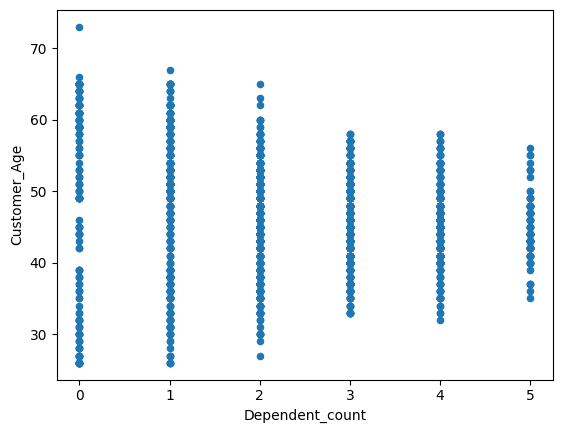

In [28]:
#### Show Dependent_count vs Customer_Age scatter plot
pdf.plot(kind='scatter', x='Dependent_count', y='Customer_Age')

There is a negative correlation between the customer age and their dependent count. However based on the scatter plot there seems to be no clear trend, and could imply that these 2 factors are not a good variable to correlate.

#### Months_Inactive_12_mon vs Credit_Limit

In [29]:
#### Get Months_Inactive_12_mon vs Credit_Limit correlation
pdf[['Months_Inactive_12_mon', 'Credit_Limit']].corr()

,Months_Inactive_12_mon,Credit_Limit
Months_Inactive_12_mon,1.00000,-0.01215
Credit_Limit,-0.01215,1.00000


<Axes: xlabel='Months_Inactive_12_mon', ylabel='Credit_Limit'>

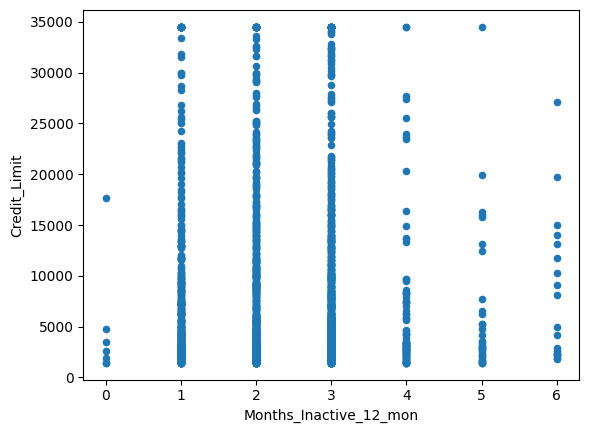

In [30]:
#### Show Months_Inactive_12_mon vs Credit_Limit scatter plot
pdf.plot(kind='scatter', x='Months_Inactive_12_mon', y='Credit_Limit')

Similar to the previous correlation, the months inactive might not be a suitable correlation to a customers credit limit. Altough it shows a negative correlation, which is often the case it might often come to fruition that most of the time it could be non-dependence or no relationship at all.

#### Dependent_count vs Total_Trans_Amt

In [31]:
#### Get Dependent_count vs Total_Trans_Amt correlation
pdf[['Dependent_count', 'Total_Trans_Amt']].corr()

,Dependent_count,Total_Trans_Amt
Dependent_count,1.000000,0.056077
Total_Trans_Amt,0.056077,1.000000


<Axes: xlabel='Dependent_count', ylabel='Total_Trans_Amt'>

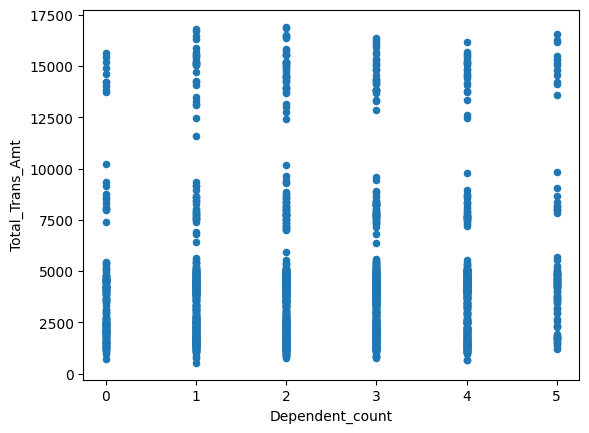

In [32]:
#### Show Dependent_count vs Total_Trans_Amt scatter plot
pdf.plot(kind='scatter', x='Dependent_count', y='Total_Trans_Amt')

Similar to the previous correlations, it would seem that there is not an established trend between the correlation of total transaction amount to one's dependent count despite the correlation being positive, however there could be a posibility if we trim down the data set or such cases.

#### Credit_Limit vs Total_Trans_Amt

In [33]:
#### Get Credit_Limit vs Total_Trans_Amt correlation
pdf[['Credit_Limit', 'Total_Trans_Amt']].corr()

,Credit_Limit,Total_Trans_Amt
Credit_Limit,1.000000,0.176836
Total_Trans_Amt,0.176836,1.000000


<Axes: xlabel='Credit_Limit', ylabel='Total_Trans_Amt'>

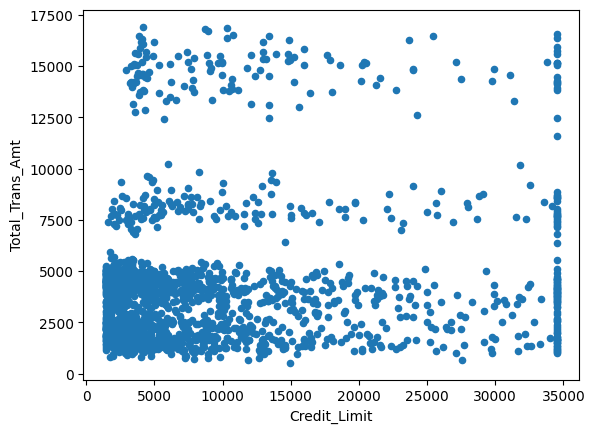

In [34]:
#### Show Credit_Limit vs Total_Trans_Amt scatter plot
pdf.plot(kind='scatter', x='Credit_Limit', y='Total_Trans_Amt')

As for this correlation, we can now see hints of a positive correlation, that as the credit limit increases the total transaction amount tend to increase as well, however this could be identified as weak since there is still a myriad amount of data spread, however, it forms a coherent trend.